# Run a pipeline adding a custom algorithm

This process will run the entire pipeline described in a configuration file and will add a custom algorithm to it

# Using a Custom algorithm that process each image individually

## Import dependencies

In [1]:
%load_ext autoreload
%autoreload 2
from paidiverpy.pipeline import Pipeline

## Instantiate the Pipeline class

When you instantiate the pipeline class, it will install some dependencies described in the configuration file that are necessary for the custom algorithm

In [2]:
pipeline = Pipeline(config_file_path="../config_files/config_custom_algorithm.yml")

☁ paidiverpy ☁  |       INFO | 2026-05-09 16:57:55 | No dataset UUID found in the dataset metadata. A new UUID has been generated: 6aad05a7-fba7-4308-a8eb-ecdefc1550a3


This occurs because of the following step that you added in the conf file:

```
steps:
    ...

  - custom:
      name: "min_max_data"
      file_path: "/mnt/noc/code/paidiver/paidiverpy/examples/custom_algorithms/custom_algorithm_example.py"
      class_name: "MyMethod"
      dependencies: "scikit-learn"
      params:
        feature_range: (0, 1)
```

In this case, you are saying that you need to install scikit-learn to use the custom algorithm

In [3]:
pipeline.config

{
    "general": {
        "name": "raw",
        "step_name": "open",
        "sample_data": "benthic_csv",
        "input_path": "/home/tobfer/.paidiverpy_cache/benthic_csv/images",
        "output_path": "output",
        "metadata_path": "/home/tobfer/.paidiverpy_cache/benthic_csv/metadata/metadata_benthic_csv.csv",
        "metadata_type": "CSV_FILE",
        "image_open_args": "PNG",
        "append_data_to_metadata": "/home/tobfer/.paidiverpy_cache/benthic_csv/metadata/appended_metadata_benthic_csv.csv",
        "n_jobs": 1,
        "track_changes": true,
        "rename": "datetime",
        "sampling": [
            {
                "name": "sampling",
                "step_name": "sampling",
                "test": false,
                "params": {
                    "value": 0.1,
                    "raise_error": false
                },
                "mode": "percent"
            }
        ]
    },
    "steps": [
        {
            "name": "colour_correction",
            "step_name": "colour",
            "test": false,
            "params": {
                "method": "opencv",
                "invert_colours": false,
                "raise_error": false
            },
            "mode": "grayscale"
        },
        {
            "name": "min_max_data",
            "file_path": "example",
            "class_name": "MyCustomClass",
            "step_name": "custom",
            "test": false,
            "processing_type": "image",
            "dependencies": "scikit-learn",
            "params": {
                "raise_error": false,
                "feature_range": "(0, 1)"
            }
        }
    ]
}

In [4]:
# See the pipeline steps. Click in a step to see more information about it
pipeline

In [5]:
# See the pipeline steps in json format
pipeline.steps

[('raw',
  paidiverpy.open_layer.open_layer.OpenLayer,
  {'name': 'raw',
   'step_name': 'open',
   'sample_data': 'benthic_csv',
   'input_path': PosixPath('/home/tobfer/.paidiverpy_cache/benthic_csv/images'),
   'output_path': PosixPath('output'),
   'metadata_path': PosixPath('/home/tobfer/.paidiverpy_cache/benthic_csv/metadata/metadata_benthic_csv.csv'),
   'metadata_type': 'CSV_FILE',
   'image_open_args': 'PNG',
   'append_data_to_metadata': '/home/tobfer/.paidiverpy_cache/benthic_csv/metadata/appended_metadata_benthic_csv.csv',
   'n_jobs': 1,
   'track_changes': True,
   'rename': 'datetime',
   'sampling': [{'name': 'sampling',
     'step_name': 'sampling',
     'test': False,
     'params': {'value': 0.1, 'raise_error': False},
     'mode': 'percent'}]}),
 ('colour_correction',
  paidiverpy.colour_layer.colour_layer.ColourLayer,
  {'name': 'colour_correction',
   'step_name': 'colour',
   'test': False,
   'params': {'method': 'opencv',
    'invert_colours': False,
    'raise

The `min_max_data` is a custom algorithm available in `file_path`: `/mnt/noc/code/paidiver/paidiverpy/examples/custom_algorithms/custom_algorithm_example.py`

In [6]:
# Run the pipeline
pipeline.run()

☁ paidiverpy ☁  |       INFO | 2026-05-09 16:57:55 | Processing images using 1 cores


☁ paidiverpy ☁  |       INFO | 2026-05-09 16:57:55 | Running step 0: raw - OpenLayer


☁ paidiverpy ☁  |       INFO | 2026-05-09 16:57:55 | Step 0 completed


☁ paidiverpy ☁  |       INFO | 2026-05-09 16:57:55 | Running step 1: colour_correction - ColourLayer


☁ paidiverpy ☁  |       INFO | 2026-05-09 16:57:55 | Step 1 completed


☁ paidiverpy ☁  |       INFO | 2026-05-09 16:57:55 | Running step 2: min_max_data - CustomLayer


☁ paidiverpy ☁  |       INFO | 2026-05-09 16:57:55 | Step 2 completed



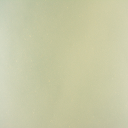
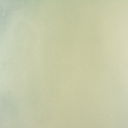
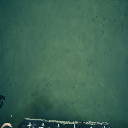
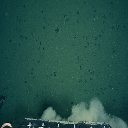
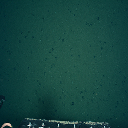
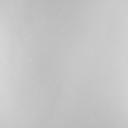
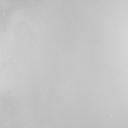
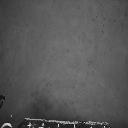
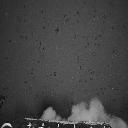
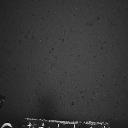
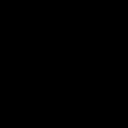
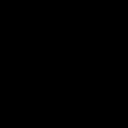
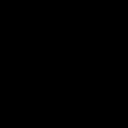
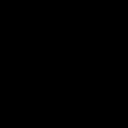
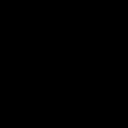

In [7]:
# See the images output
pipeline.images

# Using a Custom algorithm that process the entire dataset

In [8]:
pipeline = Pipeline(config_file_path="../config_files/config_custom_algorithm_dataset.yml")

☁ paidiverpy ☁  |       INFO | 2026-05-09 16:57:56 | No dataset UUID found in the dataset metadata. A new UUID has been generated: c840224d-2aa4-427c-81a7-49ee9e9676c1


This occurs because of the following step that you added in the conf file:

```
steps:
    ...

  - custom:
      name: "min_max_data"
      file_path: "/mnt/noc/code/paidiver/paidiverpy/examples/custom_algorithms/custom_algorithm_example_dataset.py"
      class_name: "MyMethod"
      processing_type: "dataset"    
      dependencies: "scikit-learn"
      params:
        feature_range: (0, 1)
```

In this case, you are saying that you need to install scikit-learn to use the custom algorithm.

And you are also adding the flag `processing_type` and setting it to `dataset`, which means that the custom algorithm will have access to the whole dataset at once

In [9]:
pipeline.config

{
    "general": {
        "name": "raw",
        "step_name": "open",
        "sample_data": "benthic_csv",
        "input_path": "/home/tobfer/.paidiverpy_cache/benthic_csv/images",
        "output_path": "output",
        "metadata_path": "/home/tobfer/.paidiverpy_cache/benthic_csv/metadata/metadata_benthic_csv.csv",
        "metadata_type": "CSV_FILE",
        "image_open_args": "PNG",
        "append_data_to_metadata": "/home/tobfer/.paidiverpy_cache/benthic_csv/metadata/appended_metadata_benthic_csv.csv",
        "n_jobs": 1,
        "track_changes": true,
        "rename": "datetime",
        "sampling": [
            {
                "name": "sampling",
                "step_name": "sampling",
                "test": false,
                "params": {
                    "value": 0.1,
                    "raise_error": false
                },
                "mode": "percent"
            }
        ]
    },
    "steps": [
        {
            "name": "colour_correction",
            "step_name": "colour",
            "test": false,
            "params": {
                "method": "opencv",
                "invert_colours": false,
                "raise_error": false
            },
            "mode": "grayscale"
        },
        {
            "name": "min_max_data_dataset",
            "file_path": "example_dataset",
            "class_name": "MyDatasetCustomClass",
            "step_name": "custom",
            "test": false,
            "processing_type": "dataset",
            "dependencies": "scikit-learn",
            "params": {
                "raise_error": false,
                "feature_range": "(0, 1)"
            }
        }
    ]
}

In [10]:
pipeline.run()

☁ paidiverpy ☁  |       INFO | 2026-05-09 16:57:56 | Processing images using 1 cores


☁ paidiverpy ☁  |       INFO | 2026-05-09 16:57:56 | Running step 0: raw - OpenLayer


☁ paidiverpy ☁  |       INFO | 2026-05-09 16:57:56 | Step 0 completed


☁ paidiverpy ☁  |       INFO | 2026-05-09 16:57:56 | Running step 1: colour_correction - ColourLayer


☁ paidiverpy ☁  |       INFO | 2026-05-09 16:57:56 | Step 1 completed


☁ paidiverpy ☁  |       INFO | 2026-05-09 16:57:56 | Running step 2: min_max_data_dataset - CustomLayer


☁ paidiverpy ☁  |       INFO | 2026-05-09 16:57:56 | Step 2 completed



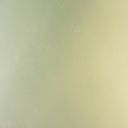
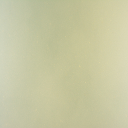
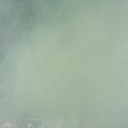
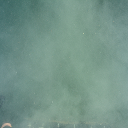
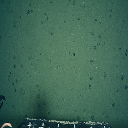
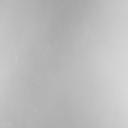
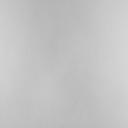
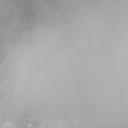
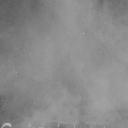
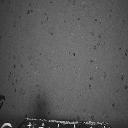
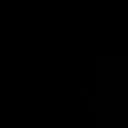
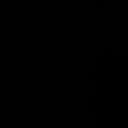
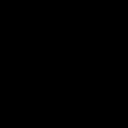
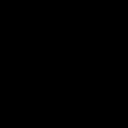
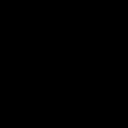

In [11]:
pipeline.images()